# Seed Averaging — Option A: Full-Data Training

Train N CatBoost models on the **entire training set** (no CV splits), each with a different
random seed. Average the test predictions.

**vs Option B (CV-based)**: Option A gives each model more data (100% vs 80% per fold)
but cannot estimate the AUC of the averaged model. Use the CV AUC from Option B
as the reference estimate.

Suitable for running on a remote GPU server — no interaction needed after launch.

## Imports & Data

In [1]:
import numpy as np
import pandas as pd
import subprocess
import time
from pathlib import Path
from sklearn.metrics import roc_auc_score
import catboost as cb

KAGGLE_DATA = Path('/kaggle/input/playground-series-s6e2')
LOCAL_DATA  = Path('data')
DATA_DIR    = KAGGLE_DATA if KAGGLE_DATA.exists() else LOCAL_DATA

def prep(df):
    df = df.copy()
    df.columns = df.columns.str.strip().str.lower().str.replace(r'\s+', '_', regex=True)
    if 'heart_disease' in df.columns:
        df['heart_disease'] = df['heart_disease'].map({'Absence': 0, 'Presence': 1})
    return df

train = prep(pd.read_csv(DATA_DIR / 'train.csv'))
test  = prep(pd.read_csv(DATA_DIR / 'test.csv'))
ss    = pd.read_csv(DATA_DIR / 'sample_submission.csv')

FEATURES     = [c for c in train.columns if c not in ['heart_disease', 'id']]
CAT_FEATURES = ['sex', 'chest_pain_type', 'fbs_over_120', 'ekg_results',
                'exercise_angina', 'slope_of_st', 'number_of_vessels_fluro', 'thallium']

X      = train[FEATURES]
y      = train['heart_disease'].values
X_test = test[FEATURES]

print(f'Train: {X.shape}    Test: {X_test.shape}')

Train: (630000, 13)    Test: (270000, 13)


## Configuration

In [2]:
N_SEEDS = 20       # more seeds than Option B — each fit is faster (no CV), so we can afford more
SEEDS   = list(range(N_SEEDS))

BASE_PARAMS = dict(
    iterations=500, learning_rate=0.1, depth=6,
    task_type='GPU', cat_features=CAT_FEATURES,
    verbose=0
    # random_state set per seed in the loop
)

# Reference AUC from Option B (CV-based seed averaging)
# Update this once Option B has run
OPTION_B_AUC    = None   # e.g. 0.95550 — fill in after running Option B
SINGLE_SEED_AUC = 0.95533  # single-model 5-fold CV AUC

print(f'Seeds: {N_SEEDS}   Total fits: {N_SEEDS}  (one per seed, full data each)')
print(f'Estimated time: ~{N_SEEDS * 30 // 60} min on GPU')

Seeds: 20   Total fits: 20  (one per seed, full data each)
Estimated time: ~10 min on GPU


## Training Loop

In [3]:
test_preds = np.zeros((N_SEEDS, len(X_test)))
fit_times  = []

for s, seed in enumerate(SEEDS):
    t0 = time.time()
    m  = cb.CatBoostClassifier(**BASE_PARAMS, random_state=seed)
    m.fit(X, y)
    test_preds[s] = m.predict_proba(X_test)[:, 1]
    elapsed = time.time() - t0
    fit_times.append(elapsed)

    # Running ensemble prediction
    running_avg = test_preds[:s+1].mean(axis=0)
    print(f'seed={seed:2d}  fit={elapsed:.1f}s  '
          f'running_avg: mean={running_avg.mean():.4f}  '
          f'std={running_avg.std():.4f}  '
          f'[{running_avg.min():.3f}, {running_avg.max():.3f}]')

print(f'\nTotal time: {sum(fit_times)/60:.1f} min   '
      f'Mean per model: {np.mean(fit_times):.1f}s')

seed= 0  fit=20.1s  running_avg: mean=0.4499  std=0.4069  [0.000, 1.000]


seed= 1  fit=19.8s  running_avg: mean=0.4497  std=0.4069  [0.000, 1.000]


seed= 2  fit=19.9s  running_avg: mean=0.4498  std=0.4069  [0.000, 1.000]


seed= 3  fit=19.9s  running_avg: mean=0.4498  std=0.4069  [0.000, 1.000]


seed= 4  fit=20.0s  running_avg: mean=0.4498  std=0.4069  [0.000, 1.000]


...

seed= 7  fit=19.9s  running_avg: mean=0.4498  std=0.4069  [0.000, 1.000]


seed= 8  fit=20.1s  running_avg: mean=0.4498  std=0.4069  [0.000, 1.000]


seed= 9  fit=19.6s  running_avg: mean=0.4498  std=0.4069  [0.000, 1.000]
seed=10  fit=24.0s  running_avg: mean=0.4498  std=0.4069  [0.000, 1.000]
seed=11  fit=19.4s  running_avg: mean=0.4498  std=0.4069  [0.000, 1.000]
seed=12  fit=20.9s  running_avg: mean=0.4498  std=0.4069  [0.000, 1.000]


seed=13  fit=22.0s  running_avg: mean=0.4498  std=0.4069  [0.000, 1.000]
seed=14  fit=19.5s  running_avg: mean=0.4499  std=0.4069  [0.000, 1.000]
seed=15  fit=20.4s  running_avg: mean=0.4498  std=0.4069  [0.000, 1.000]
seed=16  fit=23.6s  running_avg: mean=0.4498  std=0.4069  [0.000, 1.000]
seed=17  fit=20.1s  running_avg: mean=0.4499  std=0.4069  [0.000, 1.000]


seed=18  fit=19.9s  running_avg: mean=0.4499  std=0.4069  [0.000, 1.000]
seed=19  fit=20.0s  running_avg: mean=0.4498  std=0.4068  [0.000, 1.000]

Total time: 6.8 min   Mean per model: 20.5s


## Prediction Stability Analysis

Check how much the predictions change as we add more seeds.
When the curve flattens, adding more seeds has diminishing returns.

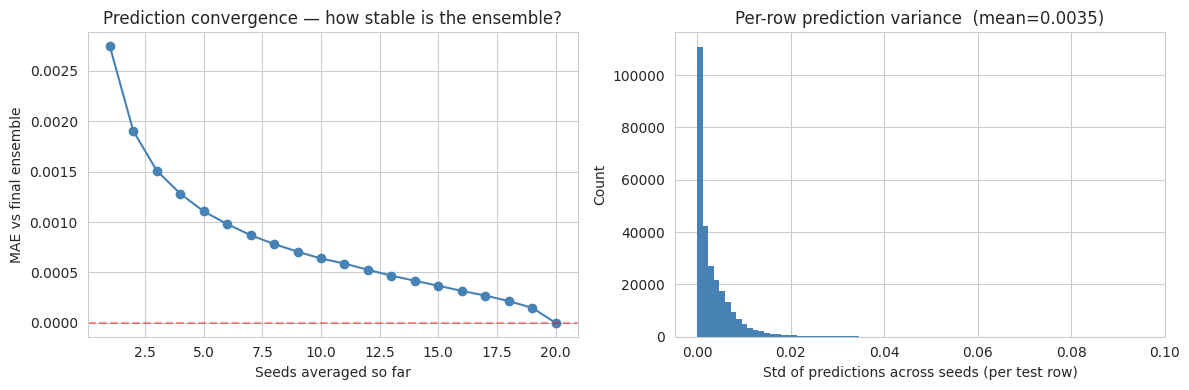

Per-row prediction std: mean=0.0035  max=0.0954  p95=0.0117


In [4]:
import matplotlib.pyplot as plt

# Measure how much the ensemble prediction changes as we add each seed
# Use mean absolute difference vs the final N-seed ensemble
final_avg = test_preds.mean(axis=0)
diffs = [
    np.abs(test_preds[:k+1].mean(axis=0) - final_avg).mean()
    for k in range(N_SEEDS)
]

# Also: std of individual model predictions per test row
per_row_std = test_preds.std(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(1, N_SEEDS + 1), diffs, 'o-', color='steelblue')
axes[0].set_xlabel('Seeds averaged so far')
axes[0].set_ylabel('MAE vs final ensemble')
axes[0].set_title('Prediction convergence — how stable is the ensemble?')
axes[0].axhline(0, color='red', linestyle='--', alpha=0.4)

axes[1].hist(per_row_std, bins=80, color='steelblue', edgecolor='none')
axes[1].set_xlabel('Std of predictions across seeds (per test row)')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Per-row prediction variance  (mean={per_row_std.mean():.4f})')

plt.tight_layout()
plt.show()

print(f'Per-row prediction std: mean={per_row_std.mean():.4f}  '
      f'max={per_row_std.max():.4f}  '
      f'p95={np.percentile(per_row_std, 95):.4f}')

## Save & Compare with Option B

In [5]:
test_averaged = test_preds.mean(axis=0)
np.save('submissions/test_cat_seedavg_fulldata.npy', test_averaged)
print(f'Saved {N_SEEDS}-seed full-data average')
print(f'Predictions: mean={test_averaged.mean():.4f}  std={test_averaged.std():.4f}')

# If Option B arrays exist, compare
option_b_path = Path('submissions/test_cat_seedavg.npy')
if option_b_path.exists():
    test_b = np.load(option_b_path)
    corr = np.corrcoef(test_averaged, test_b)[0, 1]
    mae  = np.abs(test_averaged - test_b).mean()
    print(f'\nOption A vs Option B:')
    print(f'  Correlation: {corr:.6f}')
    print(f'  MAE:         {mae:.6f}')
    
    # Also try averaging A and B together
    test_ab = (test_averaged + test_b) / 2
    np.save('submissions/test_cat_seedavg_AB_combined.npy', test_ab)
    print(f'  Saved A+B combined average')

Saved 20-seed full-data average
Predictions: mean=0.4498  std=0.4068

Option A vs Option B:
  Correlation: 0.999987
  MAE:         0.000989
  Saved A+B combined average


## Submit

In [6]:
# Use Option B AUC as the CV estimate (since we can't measure it on full-data models)
cv_auc_ref = OPTION_B_AUC if OPTION_B_AUC is not None else SINGLE_SEED_AUC

submissions_to_make = [
    ('cat_seedavg_fulldata_20seeds', test_averaged, cv_auc_ref),
]

# Optionally also submit A+B combined
if option_b_path.exists():
    test_ab = np.load('submissions/test_cat_seedavg_AB_combined.npy')
    submissions_to_make.append(('cat_seedavg_AB_combined', test_ab, cv_auc_ref))

for label, preds, cv_auc in submissions_to_make:
    fname = f'submissions/{label}.csv'
    sub = ss.copy()
    sub['Heart Disease'] = preds
    sub.to_csv(fname, index=False)
    
    desc = f'{label} | cv_auc={cv_auc:.4f}'
    r = subprocess.run(
        ['kaggle', 'competitions', 'submit', '-c', 'playground-series-s6e2',
         '-f', fname, '-m', desc],
        capture_output=True, text=True
    )
    status = 'submitted' if 'successfully' in r.stdout.lower() else r.stdout.strip()[:100]
    print(f'{label}: {status}')
    print(f'  desc: {desc}')

cat_seedavg_fulldata_20seeds: submitted
  desc: cat_seedavg_fulldata_20seeds | cv_auc=0.9553
cat_seedavg_AB_combined: submitted
  desc: cat_seedavg_AB_combined | cv_auc=0.9553
